# $d_{\text{TP}}$ and ancilla-sector diagnostics — unbatched reference implementation

Verification notebook for the Trajectory Participation Dimension $d_{\text{TP}}^{(k)}$ and ancilla-sector entropy/purity $S(\rho_{\text{anc}}^{(k)})$, $\gamma(\rho_{\text{anc}}^{(k)})$, wired against the corrected unbatched `gqnn` (`models.py`). Uses single-pass `qml.Snapshot()` extraction (not the truncated-rebuild approach) since diagnostics run with `diff_method=None` — no adjoint/snapshot incompatibility applies.

This notebook is a **pipeline verification harness**, not the production 11-instance/ancilla-count sweep: it uses untrained random weights and synthetic input windows so every metric can be checked against known-exact edge cases (e.g. zero layers $\Rightarrow$ ancilla exactly in $|0\rangle$). Swap in real NARMA data and trained weights (from the instance-sweep script) before drawing any empirical conclusion from it.

Note that the models can still be trained using the batched methods, however, the metric requires non-batched model to work (either with random weights or with trained weights).

In [1]:
# Thread Limiting (prevent kernel crashes on some Linux)
import os

# Limit threads to P-cores only (i9-13900K: 8 Performance cores)
os.environ["OMP_NUM_THREADS"] = "8"
os.environ["MKL_NUM_THREADS"] = "8"
os.environ["TORCH_NUM_THREADS"] = "8"

# Intel-specific thread pinning
os.environ["KMP_AFFINITY"] = "granularity=fine,compact,1,0"

In [2]:
import sys
import os
import time
import itertools
import pandas as pd
from pathlib import Path

project_root = os.path.abspath('../..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)
print(f'Project root: {project_root}')

# Import project modules
from src.datagen import mackey_glass, generate_arma_data, generate_narma_data
from src.datagen import split_and_scale_series
from src.models import draw_circuit, gqnn_shape, gqnn
from utils.Charts import multi_plot_flat_ts, meas_plot

Project root: /home/jacob/Dropbox/Dev/Python/quantum_projects/qtsa_expressivity


In [3]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

In [4]:
### Constants
SEED = 2025
TRAIN_FRACTION = 0.7
FIGURES_DIR = Path('../reports') # Results will be saved in the data folder
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

### Initialize random seed
np.random.seed(SEED)

## Generate data for tests

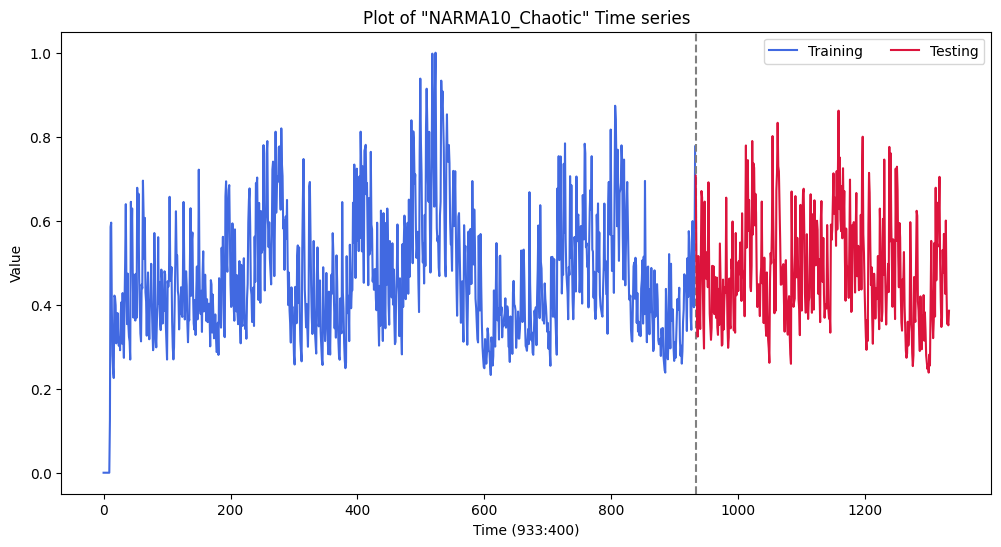

In [5]:
### Generate and plot NARMA10 time series
time_series_narma10 = generate_narma_data(order=10)
chart_name_narma10 = 'NARMA10_Chaotic'

# PLot this time series
y_temp_train, y_temp_test, _ = split_and_scale_series(time_series_narma10, TRAIN_FRACTION)
train_size, test_size = len(y_temp_train), len(y_temp_test)
x_temp_train = list(range(train_size))
x_temp_test = list(range(train_size, train_size+test_size))
multi_plot_flat_ts(
    [x_temp_train, x_temp_test], [y_temp_train, y_temp_test],
    dpi=100, rcParams=(12, 6), vert_lines=['', 'dashed'], vert_line_color='gray', 
    colors=['royalblue', 'crimson'], lines=['solid', 'solid'],
    xlabel=f'Time ({train_size}:{test_size})', ylabel='Value',
    labels=['Training', 'Testing'], title=f'Plot of "{chart_name_narma10}" Time series',
    save_plot=FIGURES_DIR / f'xfig_series_{chart_name_narma10}.png')

### Select one of the data sets

In [6]:
time_series = time_series_narma10
chart_name = chart_name_narma10

### Prepare data partition

In [7]:
### Prepare the data, scale to [0..1]
def create_io_pairs(data, window_size):
    """
    Create input-output pairs for training/testing.
    """
    inputs = []
    outputs = []
    for i in range(len(data) - window_size):
        inputs.append(data[i:i + window_size])
        outputs.append(data[i + window_size])
    return np.array(inputs), np.array(outputs)

### Data settings
window_size = 5    # 2 4 6 8
train_size = int(len(time_series) * TRAIN_FRACTION)
test_size =  len(time_series) - train_size

### Create data
train_inputs, train_outputs = create_io_pairs(time_series[:train_size], window_size)
test_inputs, test_outputs = create_io_pairs(time_series[train_size:train_size + test_size], window_size)

In [8]:
### Change the data format explicitly to tensors 
#   (not needed as by default they are correct and requires_grad=False)
train_inputs = qml.numpy.tensor(np.array(train_inputs), requires_grad=False)
train_outputs = qml.numpy.tensor(np.array(train_outputs), requires_grad=False)
test_inputs  = qml.numpy.tensor(np.array(test_inputs), requires_grad=False)
test_outputs  = qml.numpy.tensor(np.array(test_outputs), requires_grad=False)

In [9]:
print(f'Training inputs shape: {train_inputs.shape}')
print(f'Testing  inputs shape: {test_inputs.shape}')

Training inputs shape: (928, 5)
Testing  inputs shape: (395, 5)


## Single-pass snapshot extraction

Depth-$d$ snapshot is taken right after layer $d$'s reuploading block (or right after the feature map for $d=0$), giving $L{+}1$ states — $\Psi(x,\theta) \in \mathbb{C}^{2^{n_{\text{qubits}}} \times (L+1)}$, matching $|\psi_1\rangle = U_{\text{fm}}|\psi_0\rangle$ through $|\psi_{L+1}\rangle$ (no trivial $|0\rangle^{\otimes n}$ column). `diff_method=None`: forward pass only, so `qml.Snapshot()` is safe here even if training uses `diff_method='adjoint'`.

In [10]:
def extract_trajectory_single(n_layers, n_qubits, dev, 
        fm_style, reup_style, inputs, weights):
    circuit = gqnn(n_layers, n_qubits, dev, 
                   interface='autograd', diff_method=None,
                   fm_style=fm_style, reup_style=reup_style,
                   add_snaps=True)
    snaps = qml.snapshots(circuit)(inputs, weights)
    Psi = np.stack([snaps[f'depth_{d}'] for d in range(n_layers + 1)], axis=-1)
    return Psi  # (2**n_qubits, L+1)

## $d_{\text{TP}}$: Trajectory Participation Dimension

$$d_{\text{TP}}(x,\theta) = \frac{\left(\sum_n \sigma_n^2\right)^2}{\sum_n \sigma_n^4}, \qquad \sigma_n = \text{singular values of } \Psi(x,\theta)$$

`d_tp_growth` additionally computes the depth-resolved curve $d_{\text{TP}}(l)$ over partial trajectories $\Psi[:, :l+1]$ — the layer-wise reach curve, not just the endpoint value.

In [11]:
def d_tp(Psi):
    sigma = np.linalg.svd(Psi, compute_uv=False)
    num = np.sum(sigma**2)**2
    den = np.sum(sigma**4)
    return num / den

def d_tp_growth(Psi):
    L1 = Psi.shape[-1]
    return np.array([d_tp(Psi[:, :d]) for d in range(1, L1 + 1)])

def ancilla_growth(Psi, n_qubits, n_ancilla):
    # Psi: (2**n_qubits, L+1) — per-depth *instantaneous* state, not cumulative like d_tp_growth
    L1 = Psi.shape[-1]
    entropies, purities = [], []
    for d in range(L1):
        rho_d = ancilla_reduced_state(Psi[:, d], n_qubits, n_ancilla)
        e_d, p_d = ancilla_entropy_and_purity(rho_d)
        entropies.append(e_d)
        purities.append(p_d)
    return np.array(entropies), np.array(purities)

## Ancilla-sector reduced state: entropy $S$ and purity $\gamma$

Ancilla wires are assumed to be contiguous and trailing (`wires[n_features:n_qubits]`), consistent with `gqnn`'s wire layout ($n_{\text{qubits}} = \text{window\_size} + n_{\text{ancilla}}$, features on the first `window_size` wires). A flat reshape then performs the system/ancilla Schmidt split correctly under PennyLane's wire ordering.

$$\rho_{\text{anc}} = \mathrm{Tr}_{\text{sys}}\left(|\psi\rangle\langle\psi|\right), \qquad S(\rho_{\text{anc}}) = -\mathrm{Tr}(\rho_{\text{anc}}\log \rho_{\text{anc}}), \qquad \gamma(\rho_{\text{anc}}) = \mathrm{Tr}(\rho_{\text{anc}}^2)$$

In [12]:
def ancilla_reduced_state(psi, n_qubits, n_ancilla):
    n_sys = n_qubits - n_ancilla
    mat = np.reshape(psi, (2**n_sys, 2**n_ancilla))
    rho_anc = mat.conj().T @ mat
    return rho_anc

def ancilla_entropy_and_purity(rho_anc):
    eigvals = np.linalg.eigvalsh(rho_anc)
    eigvals = np.clip(eigvals.real, 0, None)
    purity = np.sum(eigvals**2)
    nz = eigvals[eigvals > 1e-12]
    entropy = -np.sum(nz * np.log(nz))
    return entropy, purity

## Configuration for verification run

Random untrained weights, a single synthetic NARMA-like window (uniform noise standing in for real data — replace `test_x` with an actual held-out sample before drawing conclusions). `window_size=5`, `n_ancilla=2` matches the empirical IQR-widening threshold from the refresher.

In [13]:
n_ancilla = 3
n_qubits = window_size + n_ancilla
n_layers = 20
fm_style = 'zzfm'
reup_style = 'X'
weights_scaler = 0.05

dev_diag = qml.device('default.qubit', wires=n_qubits)

shape = gqnn_shape(n_layers, n_qubits)
weights = np.random.uniform(-np.pi, np.pi, shape) * weights_scaler
test_x = train_inputs[500]

print(f'n_qubits={n_qubits}, n_layers={n_layers}, weight shape={shape}, test_x={np.round(test_x, 3)}')

n_qubits=8, n_layers=20, weight shape=(20, 8, 3), test_x=[0.785 0.711 0.556 0.501 0.545]


## Verification 1 — snapshot normalization (unitarity check)

Every intermediate state should have unit norm; a failure here means the circuit isn't unitary as constructed (wrong wire indexing, a stray non-unitary op, etc.) rather than anything about the metrics themselves.

In [14]:
Psi = extract_trajectory_single(n_layers, n_qubits, dev_diag, 
            fm_style, reup_style, test_x, weights)
print(f'Psi shape: {Psi.shape}  (expected ({2**n_qubits}, {n_layers + 1}))')

norms = np.linalg.norm(Psi, axis=0)
print('Per-depth state norms:', np.round(norms, 10))
assert np.allclose(norms, 1.0, atol=1e-8), 'Non-unitary snapshot detected — check circuit construction'
print('PASS: all snapshot states normalized to 1')

Psi shape: (256, 21)  (expected (256, 21))
Per-depth state norms: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
PASS: all snapshot states normalized to 1


## Verification 2 — $d_{\text{TP}}$ bounds and depth-resolved growth curve

$d_{\text{TP}}$ is a participation ratio over at most $L{+}1$ vectors in a $2^{n_{\text{qubits}}}$-dimensional space, so it must satisfy $1 \le d_{\text{TP}} \le \min(2^{n_{\text{qubits}}}, L+1)$ at every partial depth.

d_TP(full trajectory) = 19.0847   (bounds: [1, 21])
d_TP growth by depth : [ 1.      1.9857  2.9489  3.9267  4.9022  5.8321  6.7948  7.7243  8.5984
  9.4943 10.3734 11.2906 12.2072 13.1083 14.0278 14.9015 15.749  16.6369
 17.4611 18.2782 19.0847]
PASS: d_TP within [1, min(2**n_qubits, L+1)] at every depth


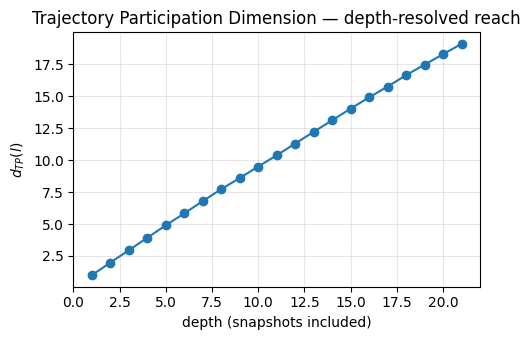

In [15]:
dtp_final = d_tp(Psi)
dtp_curve = d_tp_growth(Psi)
upper_bound = min(2**n_qubits, n_layers + 1)

print(f'd_TP(full trajectory) = {dtp_final:.4f}   (bounds: [1, {upper_bound}])')
print('d_TP growth by depth :', np.round(dtp_curve, 4))

assert np.all(dtp_curve >= 1.0 - 1e-6) and np.all(dtp_curve <= upper_bound + 1e-6), \
    'd_TP out of theoretical bounds'
print('PASS: d_TP within [1, min(2**n_qubits, L+1)] at every depth')

plt.figure(figsize=(5, 3.5))
plt.plot(range(1, n_layers + 2), dtp_curve, marker='o')
plt.xlabel('depth (snapshots included)')
plt.ylabel(r'$d_{TP}(l)$')
plt.title('Trajectory Participation Dimension — depth-resolved reach')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Verification 3 — ancilla reduced state and entropy/purity bounds

$\rho_{\text{anc}}$ must be Hermitian, trace-1, positive-semidefinite; $S(\rho_{\text{anc}}) \in [0, n_{\text{anc}}\log 2]$; $\gamma(\rho_{\text{anc}}) \in [2^{-n_{\text{anc}}}, 1]$.

In [16]:
psi_final = Psi[:, -1]
rho_anc = ancilla_reduced_state(psi_final, n_qubits, n_ancilla)

print('Hermitian:', np.allclose(rho_anc, rho_anc.conj().T))
trace_val = np.trace(rho_anc).real
print(f'Trace: {trace_val:.10f}')
eigvals = np.linalg.eigvalsh(rho_anc).real
print('Eigenvalues:', np.round(eigvals, 6), '  (all >= 0 required)')

assert np.allclose(rho_anc, rho_anc.conj().T, atol=1e-8), 'rho_anc not Hermitian'
assert np.isclose(trace_val, 1.0, atol=1e-8), 'rho_anc not trace-1'
assert np.all(eigvals >= -1e-8), 'rho_anc not PSD'
print('PASS: rho_anc is a valid density matrix')

entropy, purity = ancilla_entropy_and_purity(rho_anc)
S_max = n_ancilla * np.log(2)
purity_min = 2.0**(-n_ancilla)
print(f'S(rho_anc)      = {entropy:.4f}   (bounds: [0, {S_max:.4f}])')
print(f'gamma(rho_anc)  = {purity:.4f}   (bounds: [{purity_min:.4f}, 1])')

assert -1e-6 <= entropy <= S_max + 1e-6, 'Entropy out of bounds'
assert purity_min - 1e-6 <= purity <= 1 + 1e-6, 'Purity out of bounds'
print('PASS: entropy and purity within theoretical bounds')

Hermitian: True
Trace: 1.0000000000
Eigenvalues: [0.053089 0.066642 0.075369 0.10732  0.123206 0.138751 0.181174 0.25445 ]   (all >= 0 required)
PASS: rho_anc is a valid density matrix
S(rho_anc)      = 1.9605   (bounds: [0, 2.0794])
gamma(rho_anc)  = 0.1565   (bounds: [0.1250, 1])
PASS: entropy and purity within theoretical bounds


## Verification 4 — exact edge case: $L=0$

With no trainable layers, ancilla wires are never touched (the feature map only acts on the first `window_size` wires) and never entangled with the system — so $\rho_{\text{anc}}$ must be *exactly* $|0\rangle\langle 0|^{\otimes n_{\text{anc}}}$: entropy $=0$, purity $=1$, to machine precision. This is a hard analytic check, not a plausibility check.

In [17]:
Psi_L0 = extract_trajectory_single(0, n_qubits, dev_diag, fm_style, reup_style, test_x, weights)
rho_anc_L0 = ancilla_reduced_state(Psi_L0[:, -1], n_qubits, n_ancilla)
entropy_L0, purity_L0 = ancilla_entropy_and_purity(rho_anc_L0)

print(f'L=0: S(rho_anc) = {entropy_L0:.2e}, gamma(rho_anc) = {purity_L0:.10f}')
assert np.isclose(entropy_L0, 0.0, atol=1e-8), 'Ancilla entangled with zero layers -- wiring bug'
assert np.isclose(purity_L0, 1.0, atol=1e-8), 'Ancilla not in pure |0><0| with zero layers -- wiring bug'
print('PASS: ancilla sector exactly separable at L=0, as required analytically')

L=0: S(rho_anc) = 8.88e-16, gamma(rho_anc) = 1.0000000000
PASS: ancilla sector exactly separable at L=0, as required analytically


## Demo — pipeline sanity sweep over ancilla count

**Synthetic data, untrained weights — this checks the pipeline runs and behaves directionally sensibly, it is not the empirical result.** Swap in trained weights and real NARMA test windows from the 11-instance sweep script for the actual experiment.

In [18]:
n_samples_demo = 8
ancilla_counts_demo = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
demo_rows = []

rng = np.random.default_rng()
for n_anc in ancilla_counts_demo:
    nq = window_size + n_anc
    dev_d = qml.device('default.qubit', wires=nq)
    shp = gqnn_shape(n_layers, nq)
    w = np.random.uniform(-np.pi, np.pi, shp) * 0.05

    dtp_vals, ent_vals, pur_vals = [], [], []
    for _ in range(n_samples_demo):
        # x = np.random.uniform(-1, 1, window_size)
        random_idx = rng.integers(0, train_inputs.shape[0]-1, endpoint=True)
        x = train_inputs[random_idx]
        Psi_i = extract_trajectory_single(n_layers, nq, dev_d, fm_style, reup_style, x, w)
        dtp_vals.append(d_tp(Psi_i))
        if n_anc > 0:
            rho_i = ancilla_reduced_state(Psi_i[:, -1], nq, n_anc)
            e_i, p_i = ancilla_entropy_and_purity(rho_i)
        else:
            e_i, p_i = 0.0, 1.0
        ent_vals.append(e_i)
        pur_vals.append(p_i)

    demo_rows.append((n_anc, np.mean(dtp_vals), np.mean(ent_vals), np.mean(pur_vals)))

print(f"{'n_ancilla':>10} {'mean d_TP':>12} {'mean S_anc':>12} {'mean purity':>12}")
for row in demo_rows:
    print(f'{row[0]:>10} {row[1]:>12.4f} {row[2]:>12.4f} {row[3]:>12.4f}')

 n_ancilla    mean d_TP   mean S_anc  mean purity
         0       9.0234       0.0000       1.0000
         1      14.4826       0.6512       0.5412
         2      17.4036       1.3088       0.2873
         3      19.1364       1.9300       0.1632
         4      19.9894       2.5185       0.0942
         5      20.4228       2.9714       0.0620
         6      20.6306       3.2138       0.0470
         7      20.7593       3.3397       0.0391
         8      20.8088       3.4049       0.0351
         9      20.7690       3.4348       0.0332


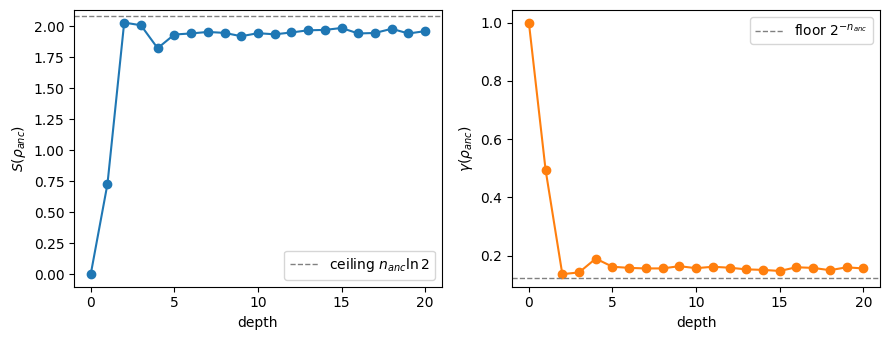

In [19]:
ent_curve, pur_curve = ancilla_growth(Psi, n_qubits, n_ancilla)
depths = range(n_layers + 1)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].plot(depths, ent_curve, marker='o')
axes[0].axhline(n_ancilla * np.log(2), color='gray', ls='--', lw=1, label=r'ceiling $n_{anc}\ln 2$')
axes[0].set_xlabel('depth'); axes[0].set_ylabel(r'$S(\rho_{anc})$'); axes[0].legend()

axes[1].plot(depths, pur_curve, marker='o', color='C1')
axes[1].axhline(2.0**(-n_ancilla), color='gray', ls='--', lw=1, label=r'floor $2^{-n_{anc}}$')
axes[1].set_xlabel('depth'); axes[1].set_ylabel(r'$\gamma(\rho_{anc})$'); axes[1].legend()

plt.tight_layout()
plt.show()

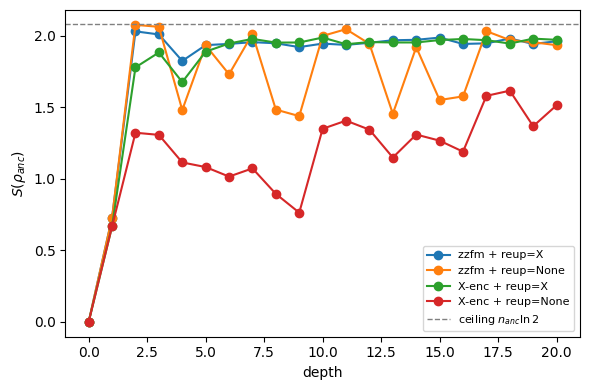

In [20]:
def ancilla_growth_sweep(configs, n_qubits, n_layers, dev, window_size, n_ancilla,
                          weights, test_x):
    # configs: list of (label, fm_style, reup_style)
    results = {}
    for label, fm_style, reup_style in configs:
        Psi = extract_trajectory_single(n_layers, n_qubits, dev, fm_style, reup_style, test_x, weights)
        ent, pur = ancilla_growth(Psi, n_qubits, n_ancilla)
        results[label] = (ent, pur)
    return results

configs = [
    ('zzfm + reup=X',   'zzfm', 'X'),    # current setup
    ('zzfm + reup=None','zzfm', None),   # isolates reuploading's contribution
    ('X-enc + reup=X',  'X',    'X'),    # isolates ZZFM richness's contribution
    ('X-enc + reup=None','X',   None),   # neither: baseline
]

sweep_results = ancilla_growth_sweep(configs, n_qubits, n_layers, dev_diag, window_size, n_ancilla,
                                      weights, test_x)

fig, ax = plt.subplots(figsize=(6, 4))
for label, (ent, pur) in sweep_results.items():
    ax.plot(range(n_layers + 1), ent, marker='o', label=label)
ax.axhline(n_ancilla * np.log(2), color='gray', ls='--', lw=1, label=r'ceiling $n_{anc}\ln 2$')
ax.set_xlabel('depth'); ax.set_ylabel(r'$S(\rho_{anc})$'); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### More tests (working)

In [21]:
def zzfm_repeats_probe(repeats_list, n_qubits, dev, window_size, test_x):
    results = {}
    for reps in repeats_list:
        @qml.qnode(dev, interface='autograd', diff_method=None)
        def circuit(inputs):
            zz_feature_map(inputs, wires=range(window_size), repeats=reps)
            return qml.state()
        psi0 = circuit(test_x)
        Psi0 = psi0.reshape(-1, 1)          # single-column trajectory: d_TP degenerates to 1 by construction
        # measure system-register participation directly instead: SVD of psi0 across a system bipartition
        rho_sys = np.outer(psi0, psi0.conj())
        purity_full = np.trace(rho_sys @ rho_sys).real
        results[reps] = purity_full          # sanity: should be 1.0 (pure state) regardless of repeats
    return results

In [22]:
def train_instance_with_checkpoints(seed, n_qubits, n_layers, dev, circuit_kwargs,
                                     train_inputs, train_outputs, epochs=50,
                                     weights_scaler=0.05, stepsize=0.5, checkpoint_every=5):
    np.random.seed(seed)
    circuit = gqnn(n_layers, n_qubits, dev, **circuit_kwargs)
    shape = gqnn_shape(n_layers, n_qubits)
    weights = np.random.uniform(-np.pi, np.pi, shape, requires_grad=True) * weights_scaler
    opt = qml.AdamOptimizer(stepsize=stepsize)
    cost_fun = cost_fun_gen(circuit, mse_cost)

    checkpoints = {0: np.copy(weights)}
    hist_cost = []
    for it in range(epochs):
        def objective_fn(w):
            return cost_fun(w, train_inputs, train_outputs)
        weights, cost = opt.step_and_cost(objective_fn, weights)
        hist_cost.append(float(cost))
        if (it + 1) % checkpoint_every == 0 or it == epochs - 1:
            checkpoints[it + 1] = np.copy(weights)

    return {'seed': seed, 'weights_final': weights, 'checkpoints': checkpoints, 'train_hist': hist_cost}

## Notes and open verification items

- **Verified analytically in this notebook:** unitarity of every snapshot, $d_{\text{TP}}$ bounds, $\rho_{\text{anc}}$ validity (Hermitian/trace-1/PSD), entropy/purity bounds, and the exact $L{=}0$ separable edge case.
- **Not verified here, still open from earlier discussion:** whether batched `qml.snapshots` broadcasting works correctly on your installed PennyLane 0.45.0 (this notebook sidesteps that by staying unbatched, one sample per call — correct but not the throughput win the batched `models_batch.py` circuit was built for).
- **Deliberate design choice, not a bug:** ancilla entropy/purity are computed from the **final-depth** state only, while $d_{\text{TP}}$ is trajectory-integrated over all $L{+}1$ depths — these are two structurally different kinds of local diagnostic and shouldn't be conflated when reporting the IQR-widening hypothesis test.
- Replace `test_x` / the demo sweep's random inputs and untrained weights with real held-out NARMA windows and the 11-instance trained weight sets before treating any output above as an empirical result.